In [2]:
from src.simulations import SPDC
from src.plotting_helpers import plot_spectrum

import numpy as np

In [3]:
# Parameters - nominal values are actually used in the experiment
# - crystal length
L_nominal = 1e-3 # m
L_vals = [1e-4, 1e-3, 1e-2]

# - crystal temperature
t_nominal = 25 # deg C
t_vals = [10, 55, 95]

# - pump beam waist
omega_0_nominal = 750e-6 # m
omega_0_vals = [10e-6, 100e-6, 350e-6]

# - pump power
P = 0.5 # W

# - ppKTP period
period = 9.325e-6 # m

# - pump wavelength
lambda_p = 532e-9 # m
lambda_s_degenerate = 1064e-9 #m

# - lambda_s = 870e-9
# - lambda_i = 1369e-9
lambda_s_min=650e-9
lambda_s_max=1850e-9
theta_s_min=0.0
theta_s_max=0.16

Signal batches:   0%|          | 0/2605 [00:00<?, ?it/s]

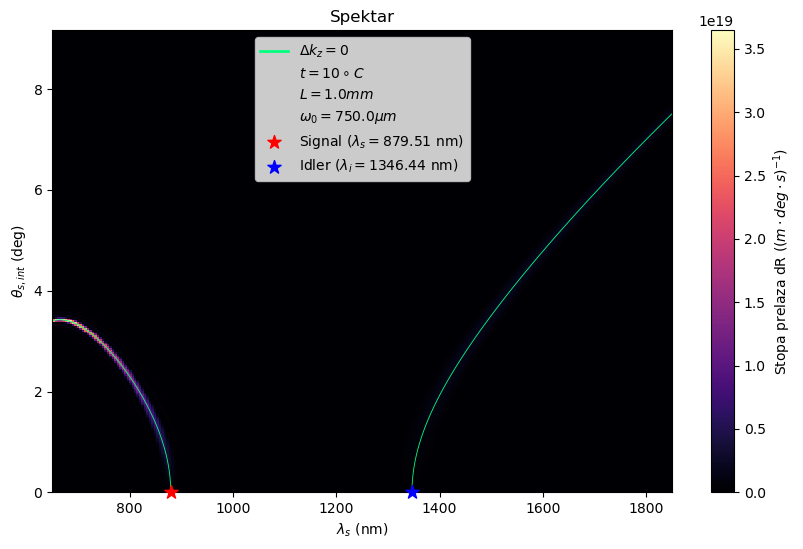

Signal batches:   0%|          | 0/2605 [00:00<?, ?it/s]

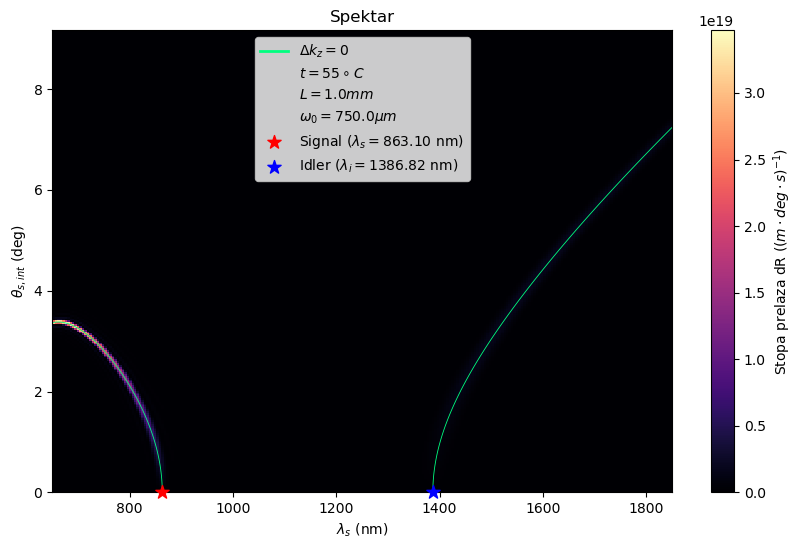

Signal batches:   0%|          | 0/2605 [00:00<?, ?it/s]

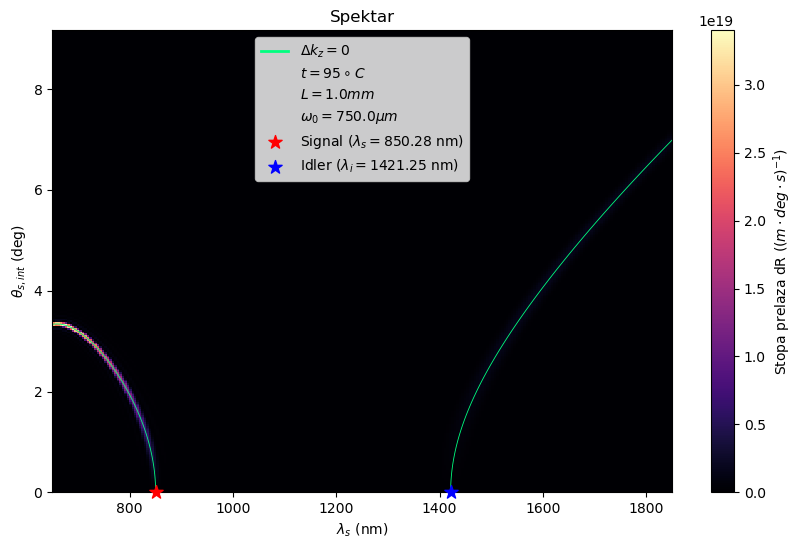

In [3]:
# t dependency
for i, t in enumerate(t_vals):
    spdc = SPDC(
        L=L_nominal,
        t=t,
        period=period,
        m=-1,
        chi_eff=6e-12,
        lambda_p=lambda_p,
        P=P,
        omega_0=omega_0_nominal,
        T_I=0,
        lambda_s_min=lambda_s_min,
        lambda_s_max=lambda_s_max,
        theta_s_min=theta_s_min,
        theta_s_max=theta_s_max,
        grid_size=250,
        N_phi=2**6,
        min_N_i=2**8,
        max_N_i=2**10,
        n_processes=9,
        signal_batch_size=24,
        seed=0,
    )
    spectrum = spdc.get_transition_rate_parallel()
    np.save("spectrum_t{i}.npy", spectrum)
    plot_spectrum(spdc, spectrum)

Signal batches:   0%|          | 0/1667 [00:00<?, ?it/s]

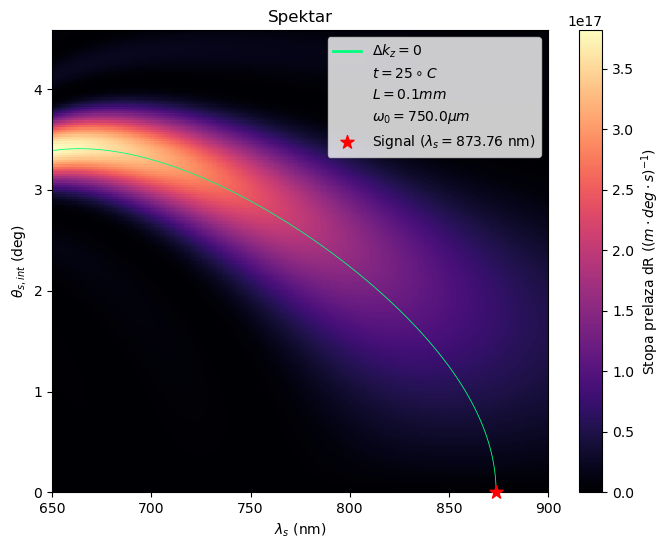

Signal batches:   0%|          | 0/1667 [00:00<?, ?it/s]

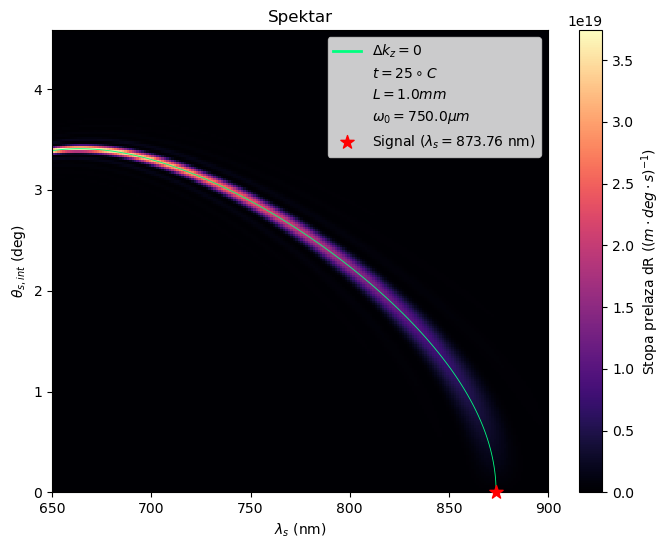

Signal batches:   0%|          | 0/1667 [00:00<?, ?it/s]

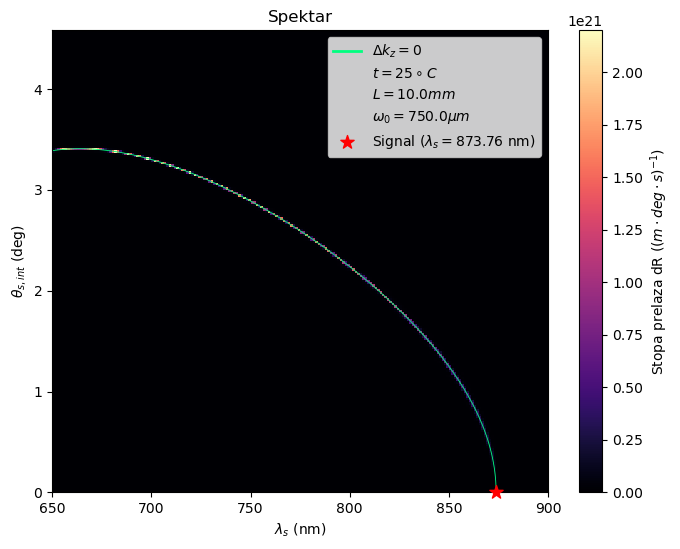

In [4]:
# L dependency
for i, L in enumerate(L_vals):
    spdc = SPDC(
        L=L,
        t=t_nominal,
        period=period,
        m=-1,
        chi_eff=6e-12,
        lambda_p=lambda_p,
        P=P,
        omega_0=omega_0_nominal,
        T_I=0,
        lambda_s_min=lambda_s_min,
        lambda_s_max=900e-9,
        theta_s_min=theta_s_min,
        theta_s_max=theta_s_max / 2,
        grid_size=200,
        N_phi=2**6,
        min_N_i=2**8,
        max_N_i=2**10,
        n_processes=9,
        signal_batch_size=24,
        seed=0,
    )
    spectrum = spdc.get_transition_rate_parallel()
    np.save(f"spectrum_L{i}.npy", spectrum)

    plot_spectrum(spdc, spectrum)

Signal batches:   0%|          | 0/1667 [00:00<?, ?it/s]

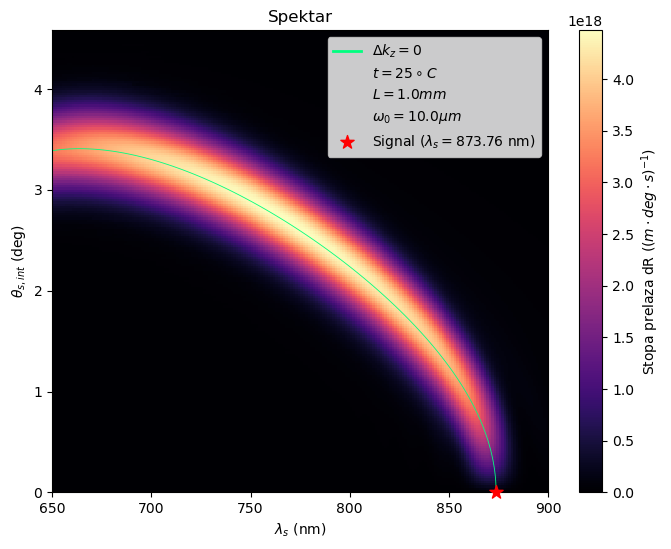

Signal batches:   0%|          | 0/1667 [00:00<?, ?it/s]

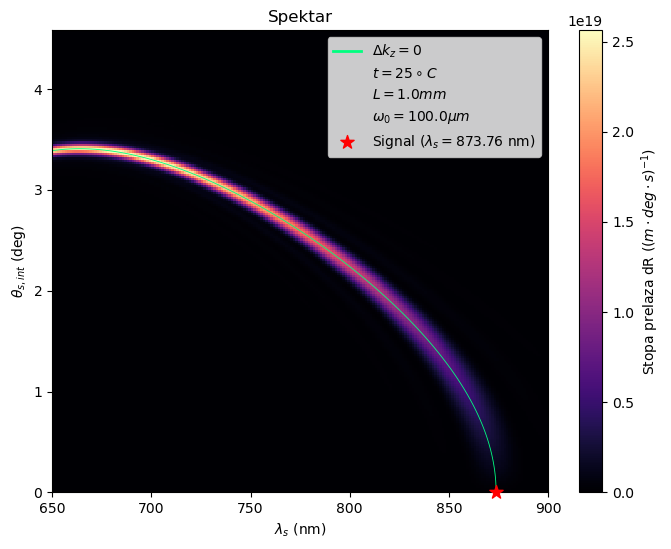

Signal batches:   0%|          | 0/1667 [00:00<?, ?it/s]

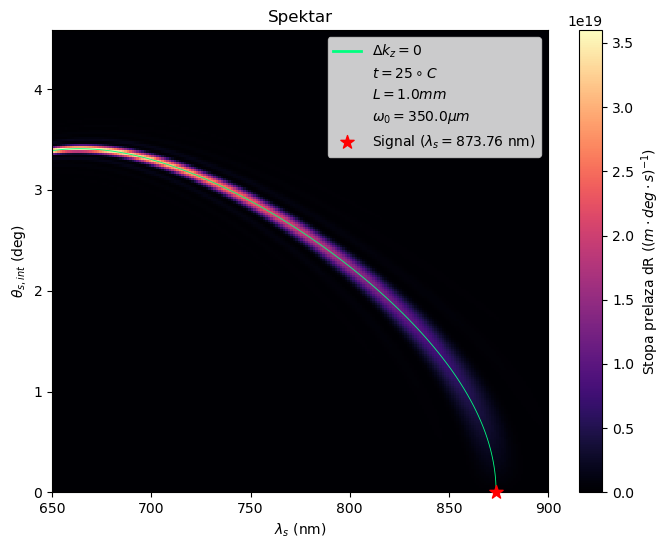

In [5]:
# omega_0 dependency
for i, omega_0 in enumerate(omega_0_vals):
    spdc = SPDC(
        L=L_nominal,
        t=t_nominal,
        period=period,
        m=-1,
        chi_eff=6e-12,
        lambda_p=lambda_p,
        P=P,
        omega_0=omega_0,
        T_I=0,
        lambda_s_min=lambda_s_min,
        lambda_s_max=900e-9,
        theta_s_min=theta_s_min,
        theta_s_max=theta_s_max / 2,
        grid_size=200,
        N_phi=2**6,
        min_N_i=2**8,
        max_N_i=2**10,
        n_processes=9,
        signal_batch_size=24,
        seed=0,
    )
    spectrum = spdc.get_transition_rate_parallel()
    np.save(f"spectrum_omega_0{i}.npy", spectrum)

    plot_spectrum(spdc, spectrum)